In [10]:
import pandas as pd

gold = pd.read_csv("monthly-gold-price.csv")
cpi = pd.read_csv("monthly-core-cpi.csv")

In [3]:
gold

,Date,Price
0,1833-01-01,18.93
1,1833-02-01,18.93
2,1833-03-01,18.93
3,1833-04-01,18.93
4,1833-05-01,18.93
...,...,...
2313,2025-10-01,4058.33
2314,2025-11-01,4087.19
2315,2025-12-01,4309.23
2316,2026-01-01,4752.75


In [11]:
cpi = cpi.rename(columns={'observation_date':'Date'})

In [12]:
cpi

,Date,CORESTICKM159SFRBATL
0,1968-01-01,3.651861
1,1968-02-01,3.673819
2,1968-03-01,4.142164
3,1968-04-01,4.155828
4,1968-05-01,4.088245
...,...,...
693,2025-10-01,3.077827
694,2025-11-01,2.954815
695,2025-12-01,3.006319
696,2026-01-01,2.979751


In [13]:
df = gold.merge(cpi,on="Date")

In [17]:
df = df.rename(columns={'Dore CPI':'Core CPI'})

In [18]:
df

,Date,Price,Core CPI
0,1968-01-01,35.50,3.651861
1,1968-02-01,36.00,3.673819
2,1968-03-01,37.00,4.142164
3,1968-04-01,37.86,4.155828
4,1968-05-01,40.70,4.088245
...,...,...,...
693,2025-10-01,4058.33,3.077827
694,2025-11-01,4087.19,2.954815
695,2025-12-01,4309.23,3.006319
696,2026-01-01,4752.75,2.979751


In [19]:
df["Real Gold"] = df["Price"]/df["Core CPI"]

In [24]:
df["Date"] = pd.to_datetime(df["Date"])

In [25]:
df

,Date,Price,Core CPI,Real Gold
0,1968-01-01,35.50,3.651861,9.721071
1,1968-02-01,36.00,3.673819,9.799066
2,1968-03-01,37.00,4.142164,8.932529
3,1968-04-01,37.86,4.155828,9.110098
4,1968-05-01,40.70,4.088245,9.955371
...,...,...,...,...
693,2025-10-01,4058.33,3.077827,1318.569887
694,2025-11-01,4087.19,2.954815,1383.230393
695,2025-12-01,4309.23,3.006319,1433.390726
696,2026-01-01,4752.75,2.979751,1595.015859


In [27]:
Allcpi = pd.read_csv("CPIAUCSL.csv")

In [29]:
Allcpi = Allcpi.rename(columns={'observation_date':'Date', 'CPIAUCSL':'All Item CPI'})

In [30]:
Allcpi

,Date,All Item CPI
0,1947-01-01,21.480
1,1947-02-01,21.620
2,1947-03-01,22.000
3,1947-04-01,22.000
4,1947-05-01,21.950
...,...,...
945,2025-10-01,NaN
946,2025-11-01,325.063
947,2025-12-01,326.031
948,2026-01-01,326.588


In [31]:
df = gold.merge(Allcpi,on="Date")

In [35]:
df["Real Gold"] = df["Price"]/df["All Item CPI"]
df

,Date,Price,All Item CPI,Real Gold
0,1947-01-01,34.71,21.480,1.615922
1,1947-02-01,34.71,21.620,1.605458
2,1947-03-01,34.71,22.000,1.577727
3,1947-04-01,34.71,22.000,1.577727
4,1947-05-01,34.71,21.950,1.581321
...,...,...,...,...
945,2025-10-01,4058.33,NaN,NaN
946,2025-11-01,4087.19,325.063,12.573532
947,2025-12-01,4309.23,326.031,13.217240
948,2026-01-01,4752.75,326.588,14.552739


In [37]:
df["Date"] = pd.to_datetime(df["Date"])

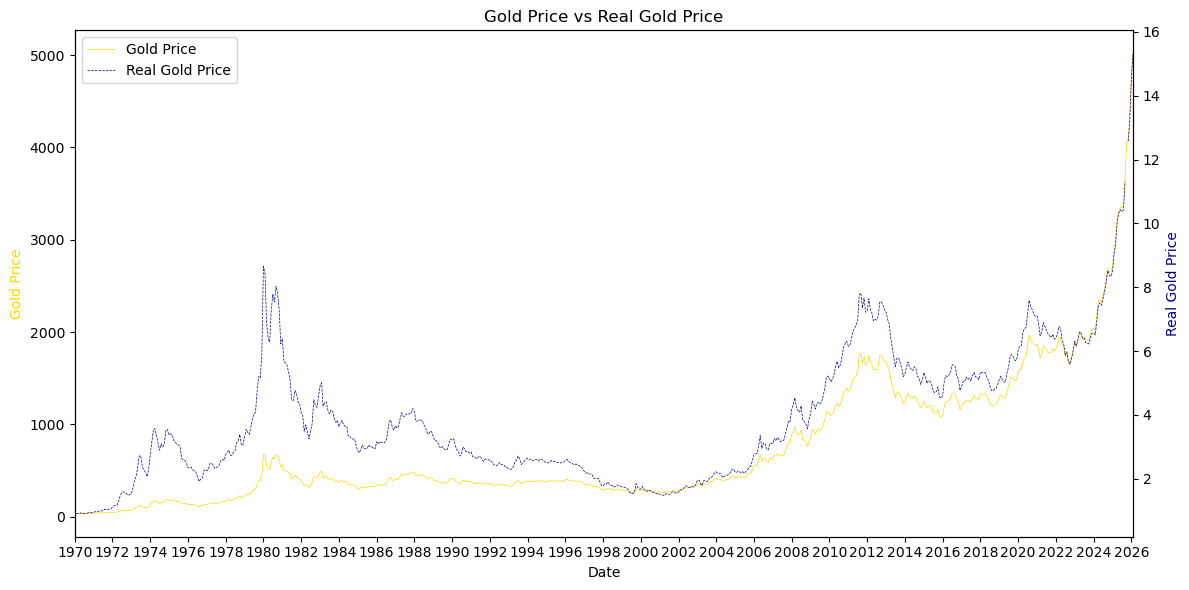

In [47]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(12,6))

# 第一条线
line1 = ax1.plot(df["Date"], df["Price"],
                 color="gold",
                 linewidth=0.5,
                 label="Gold Price")

ax1.set_ylabel("Gold Price", color="gold")

# 第二个轴
ax2 = ax1.twinx()

line2 = ax2.plot(df["Date"], df["Real Gold"],
                 color="darkblue",
                 linestyle="--",
                 linewidth=0.5,
                 label="Real Gold Price")

ax2.set_ylabel("Real Gold Price", color="darkblue")

ax1.set_xlabel("Date")

# 控制日期显示
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)

# 合并 legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="upper left")

plt.title("Gold Price vs Real Gold Price")
ax1.set_xlim(pd.Timestamp("1970-01-01"), df["Date"].max())
plt.tight_layout()
plt.savefig("gold_chart.png", dpi=300, bbox_inches="tight")
plt.show()